In [8]:
from pathlib import Path
import sys


def _project_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "src" / "forecasting").is_dir():
            return p
    return here


_root = _project_root()
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from statsmodels.tsa.seasonal import STL

import plotly.graph_objects as go
from plotly.subplots import make_subplots

from forecasting.data.loaders import load_market_data

TARGET_COL = "purchase_bid"

In [2]:
data_indexed = load_market_data("../../data/raw/iex-dam-0201-0421.csv")
data = data_indexed.reset_index()
data.sample()

,period_start,period,purchase_bid,sell_bid,mcv,mcp,final_scheduled_volume
1322,2026-02-14 18:30:00,18:30 - 18:45,19269.1,13384.9,9923.49,5335.64,9923.49


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   period_start            7008 non-null   datetime64[ns]
 1   period                  7008 non-null   object        
 2   purchase_bid            7008 non-null   float64       
 3   sell_bid                7008 non-null   float64       
 4   mcv                     7008 non-null   float64       
 5   mcp                     7008 non-null   float64       
 6   final_scheduled_volume  7008 non-null   float64       
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 383.4+ KB


In [4]:
data.describe()

,period_start,purchase_bid,sell_bid,mcv,mcp,final_scheduled_volume
count,7008,7008.000000,7008.000000,7008.000000,7008.000000,7008.000000
mean,2026-03-09 11:52:30,16193.763242,24183.723473,9307.233323,3923.179957,9306.231035
min,2026-02-01 00:00:00,8081.200000,1778.300000,1778.300000,199.650000,1778.300000
25%,2026-02-19 05:56:15,13839.875000,13997.600000,7992.825000,2463.817500,7992.825000
50%,2026-03-09 11:52:30,15949.400000,20569.500000,9308.050000,3340.530000,9308.050000
75%,2026-03-27 17:48:45,18147.700000,33011.925000,10713.052500,4500.847500,10713.052500
max,2026-04-14 23:45:00,35979.500000,65182.000000,16027.300000,10000.000000,16027.300000
std,NaN,3553.197880,13108.231730,2022.378915,2326.476772,2020.367493


## Data Visualization - naive plots

In [5]:
columns = ["purchase_bid", "sell_bid", "mcv", "mcp"]
titles  = ["Purchase Bid", "Sell Bid", "MCV", "MCP"]
colors  = ["#378ADD", "#1D9E75", "#D85A30", "#7F77DD"]

# purchase_bid, sell_bid, mcv → left y-axis (MW)
# mcp → right y-axis (₹/MWh)  — very different scale, needs its own axis

fig = go.Figure()

for col, name, color in zip(columns, titles, colors):
    fig.add_trace(go.Scatter(
        x=data["period_start"],
        y=data[col],
        mode="lines+markers",
        name=name,
        line=dict(color=color, width=2),
        marker=dict(size=5, color=color),
        yaxis="y2" if col == "mcp" else "y1",
        hovertemplate=f"<b>%{{x|%H:%M}}</b><br>{name}: %{{y:,.2f}}<extra></extra>",
    ))

fig.update_layout(
    title=dict(text="IEX Market Data", font=dict(size=18), x=0.5, xanchor="center"),
    height=520,
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(t=70, b=60, l=70, r=70),
    font=dict(family="Arial, sans-serif", size=12),
    hovermode="x unified",
    legend=dict(
        orientation="h",
        yanchor="bottom", y=1.02,
        xanchor="center", x=0.5,
        bgcolor="rgba(255,255,255,0.8)",
        bordercolor="rgba(150,150,150,0.3)",
        borderwidth=1,
    ),
    yaxis=dict(
        title="MW",
        showgrid=True,
        gridcolor="rgba(150,150,150,0.2)",
        zeroline=False,
    ),
    yaxis2=dict(
        title="₹/MWh",
        overlaying="y",
        side="right",
        showgrid=False,
        zeroline=False,
        tickfont=dict(color="#7F77DD"),
        title_font=dict(color="#7F77DD"),
    ),
)

fig.show("notebook")

### Takeaways

1. Purchase Bids 
- spike at around 7:30 am in the morning, and 6:30 pm in the evening
- A slight downtrend moving from february to march and then spikes in the evening in mid-April
2. Sell Bids
- spike at around 01:00 pm, then lower at 06:30 pm, and rise again at around 2:30 am, and lower at 07:00 pm
3. MCV
- follows almost the same trend as sell bids, but with some significant noise.
4. MCP
- whenever sell bid is low, MCP is high. capped at 10000

### Other findings
1. There is a massive simultaneous supply shortage from march 11 to 15 and demand spike during the same period.

## Data Quality & Integrity

`load_market_data` already calls `asfreq("15min")`, so any missing 15-min slot in the source CSV becomes a NaN-only row in `data`. Below we audit:

1. **Time-index continuity** — count of NaN-only rows = count of missing 15-min observations.
2. **Per-day completeness** — every day should expose 96 valid blocks; days with fewer indicate ingestion gaps.
3. **Duplicate timestamps** — must be 0 for SARIMA / asfreq pipelines.
4. **Sign and zero counts** — bid volumes and MCV should be strictly positive.

In [ ]:
total_slots = len(data)
n_missing = data["purchase_bid"].isna().sum()
print(f"Continuous 15-min slots covered : {total_slots:,}")
print(f"Slots with missing observations : {n_missing:,} ({n_missing / total_slots:.2%})")
if n_missing:
    print("\nFirst 10 missing slot timestamps:")
    print(data.loc[data["purchase_bid"].isna(), "period_start"].head(10).tolist())

valid = data.dropna(subset=["purchase_bid"])
daily_counts = (
    valid.assign(date=valid["period_start"].dt.date)
         .groupby("date").size()
)
days_short = daily_counts[daily_counts != 96]
print(f"\nDays with != 96 valid blocks    : {len(days_short)}")
if not days_short.empty:
    print(days_short.head(10))

dup_count = data["period_start"].duplicated().sum()
print(f"\nDuplicate timestamps            : {dup_count}")

print("\nNon-positive value counts:")
for col in ["purchase_bid", "sell_bid", "mcv", "mcp"]:
    n_neg = int((data[col] < 0).sum())
    n_zero = int((data[col] == 0).sum())
    print(f"  {col:14s} | negatives={n_neg:>4d} | zeros={n_zero:>4d}")

nan_audit = data.isna().sum()
print("\nNaN counts per column:")
print(nan_audit[nan_audit > 0] if nan_audit.any() else "  (no NaNs)")

Continuous 15-min slots covered : 7,680
Slots with missing observations : 0 (0.00%)

Days with != 96 valid blocks    : 0

Duplicate timestamps            : 0

Non-positive value counts:
  purchase_bid   | negatives=   0 | zeros=   0
  sell_bid       | negatives=   0 | zeros=   0
  mcv            | negatives=   0 | zeros=   0
  mcp            | negatives=   0 | zeros=   0

MCP rows ≥ 10,000 (price-cap)   : 884 (11.51%)

NaN counts per column:
  (no NaNs)


### Takeaway (from this run)

- **7,680** contiguous 15-min slots, **0** missing `purchase_bid`, **0** days with fewer than 96 blocks, **0** duplicate `period_start` — the panel is clean for SARIMA / `asfreq` workflows.
- All of `purchase_bid`, `sell_bid`, `mcv`, `mcp` are strictly positive in this extract (no zeros or negatives).
- **884 rows (11.5%)** have `mcp` at the **10,000** cap — treat these as censored in any price model; volume models are unaffected but MCP-driven features may be biased at the ceiling.
- If gaps or duplicates appear in a future extract, impute (e.g. same-block previous day) before fitting; do not train LSTM on raw zeros used as NaN placeholders.

## Temporal Context

/var/folders/g9/xjzktt7170ndt92dv26_pntc0000gn/T/ipykernel_50877/3151125472.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='period_enum', y=TARGET_COL, palette="viridis")


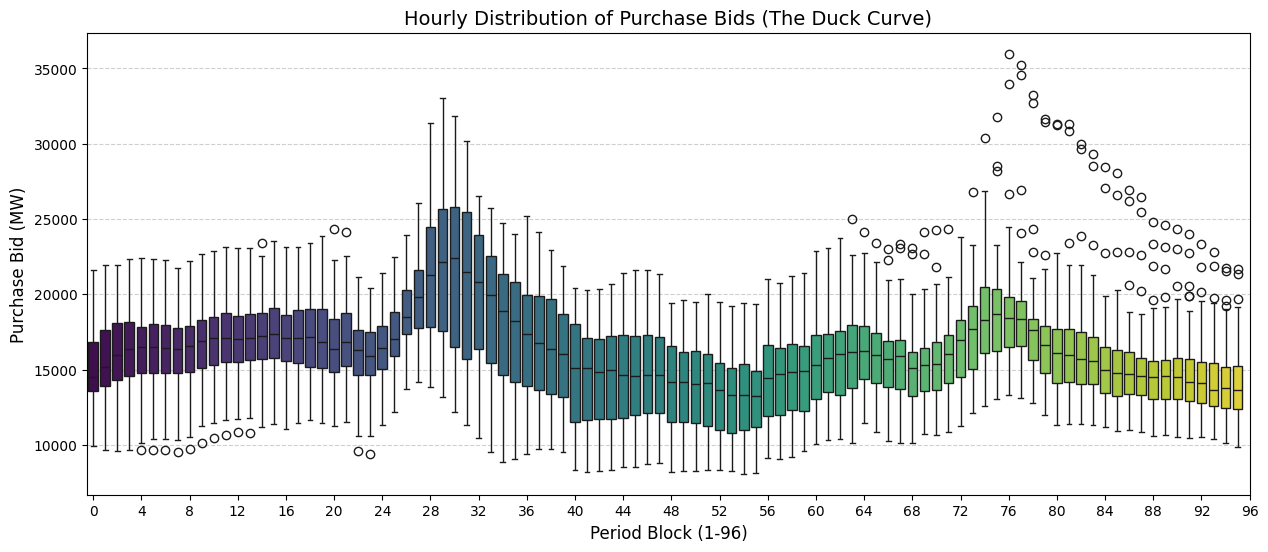

Average Bid on weekday and weekend:
day_type
Weekday    16427.944976
Weekend    14873.829830
Name: purchase_bid, dtype: float64


/var/folders/g9/xjzktt7170ndt92dv26_pntc0000gn/T/ipykernel_50877/3151125472.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='weekday_enum', y=TARGET_COL, palette="viridis")


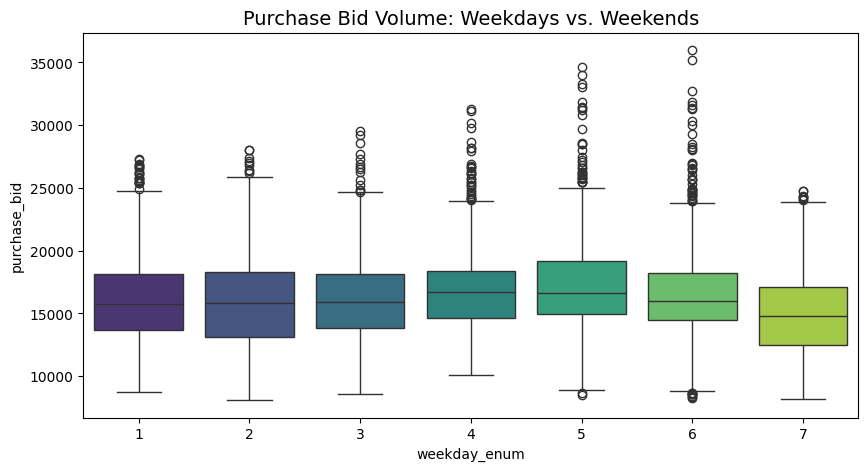

Average Bid on Holidays vs Working Days:
is_holiday
0    16288.061863
1    15140.761979
Name: purchase_bid, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

data_temporal = data.copy()

# --- 1. Hourly Profiling (The Duck Curve) ---
def plot_hourly_distribution(df):
    plt.figure(figsize=(15, 6))
    # Boxplot shows the median, quartiles, and outliers for each 15-min block
    sns.boxplot(data=df, x='period_enum', y=TARGET_COL, palette="viridis")
    plt.title("Hourly Distribution of Purchase Bids (The Duck Curve)", fontsize=14)
    plt.xlabel("Period Block (1-96)", fontsize=12)
    plt.ylabel("Purchase Bid (MW)", fontsize=12)
    plt.xticks(range(0, 97, 4), labels=range(0, 97, 4)) # Show hours on X-axis
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

# --- 2. Weekly Seasonality (Weekday vs Weekend) ---
def plot_weekly_impact(df):
    # Categorize into Weekday (1-5) and Weekend (6-7)
    df['day_type'] = df['weekday_enum'].apply(lambda x: 'Weekend' if x == 7 else 'Weekday')
    
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x='weekday_enum', y=TARGET_COL, palette="viridis")
    # sns.violinplot(data=df, x='day_type', y='purchase_bid', split=True, inner="quart", palette="Pastel1")
    plt.title("Purchase Bid Volume: Weekdays vs. Weekends", fontsize=14)
    weekday_stats = df.groupby('day_type')[TARGET_COL].mean()
    print("Average Bid on weekday and weekend:")
    print(weekday_stats)
    plt.show()

# --- 3. Holiday Identification ---
def add_holiday_flags(df):
    # List of major Indian holidays for Feb - April 2026
    # Note: These dates affect industrial load significantly
    holidays_2026 = [
        '2026-02-18', # Maha Shivaratri
        '2026-03-03', # Holi
        '2026-03-19', # Gudi Padwa / Ugadi
        '2026-03-28', # Ram Navami
        '2026-04-03', # Good Friday
        '2026-04-10', # Ambedkar Jayanti
    ]
    
    df['is_holiday'] = df['period_start'].dt.strftime('%Y-%m-%d').isin(holidays_2026).astype(int)
    
    # Check impact
    holiday_stats = df.groupby('is_holiday')[TARGET_COL].mean()
    print("Average Bid on Holidays vs Working Days:")
    print(holiday_stats)
    return df

# Execution
data_temporal["period_enum"] = data_temporal["period_start"].dt.hour * 4 + data_temporal["period_start"].dt.minute // 15 + 1
data_temporal["weekday_enum"] = data_temporal["period_start"].dt.weekday + 1

plot_hourly_distribution(data_temporal)
plot_weekly_impact(data_temporal)
data_temporal = add_holiday_flags(data_temporal)

### Takeaways
1. Purchase bids wary with period, so period_enum should be an addition to our feature set.
2. Significant difference between energy consumed on weekday over weekend.
3. Energy consumption during holiday is lower, so would be worthwhile to include is_holiday boolean.

## Distribution & Transformation Analysis

`data.describe()` gave us the central tendency. Before fitting SARIMA (which assumes Gaussian residuals) or scaling features for an LSTM, we check **shape**:

- Skewness and kurtosis per target.
- Histogram + KDE for visual asymmetry.
- Q-Q plot vs the normal distribution.
- Box-Cox optimal `λ` to suggest the variance-stabilizing transform — `λ ≈ 0` ⇒ use `log1p`, `λ ≈ 0.5` ⇒ use `sqrt`, `λ ≈ 1` ⇒ no transform needed.

Distribution moments per target:
                   mean   median        std   skew  kurtosis        iqr
purchase_bid  16405.953  15997.0   4169.599  1.822     8.582   4432.275
sell_bid      23704.252  20085.2  13786.758  0.663    -0.395  19972.400


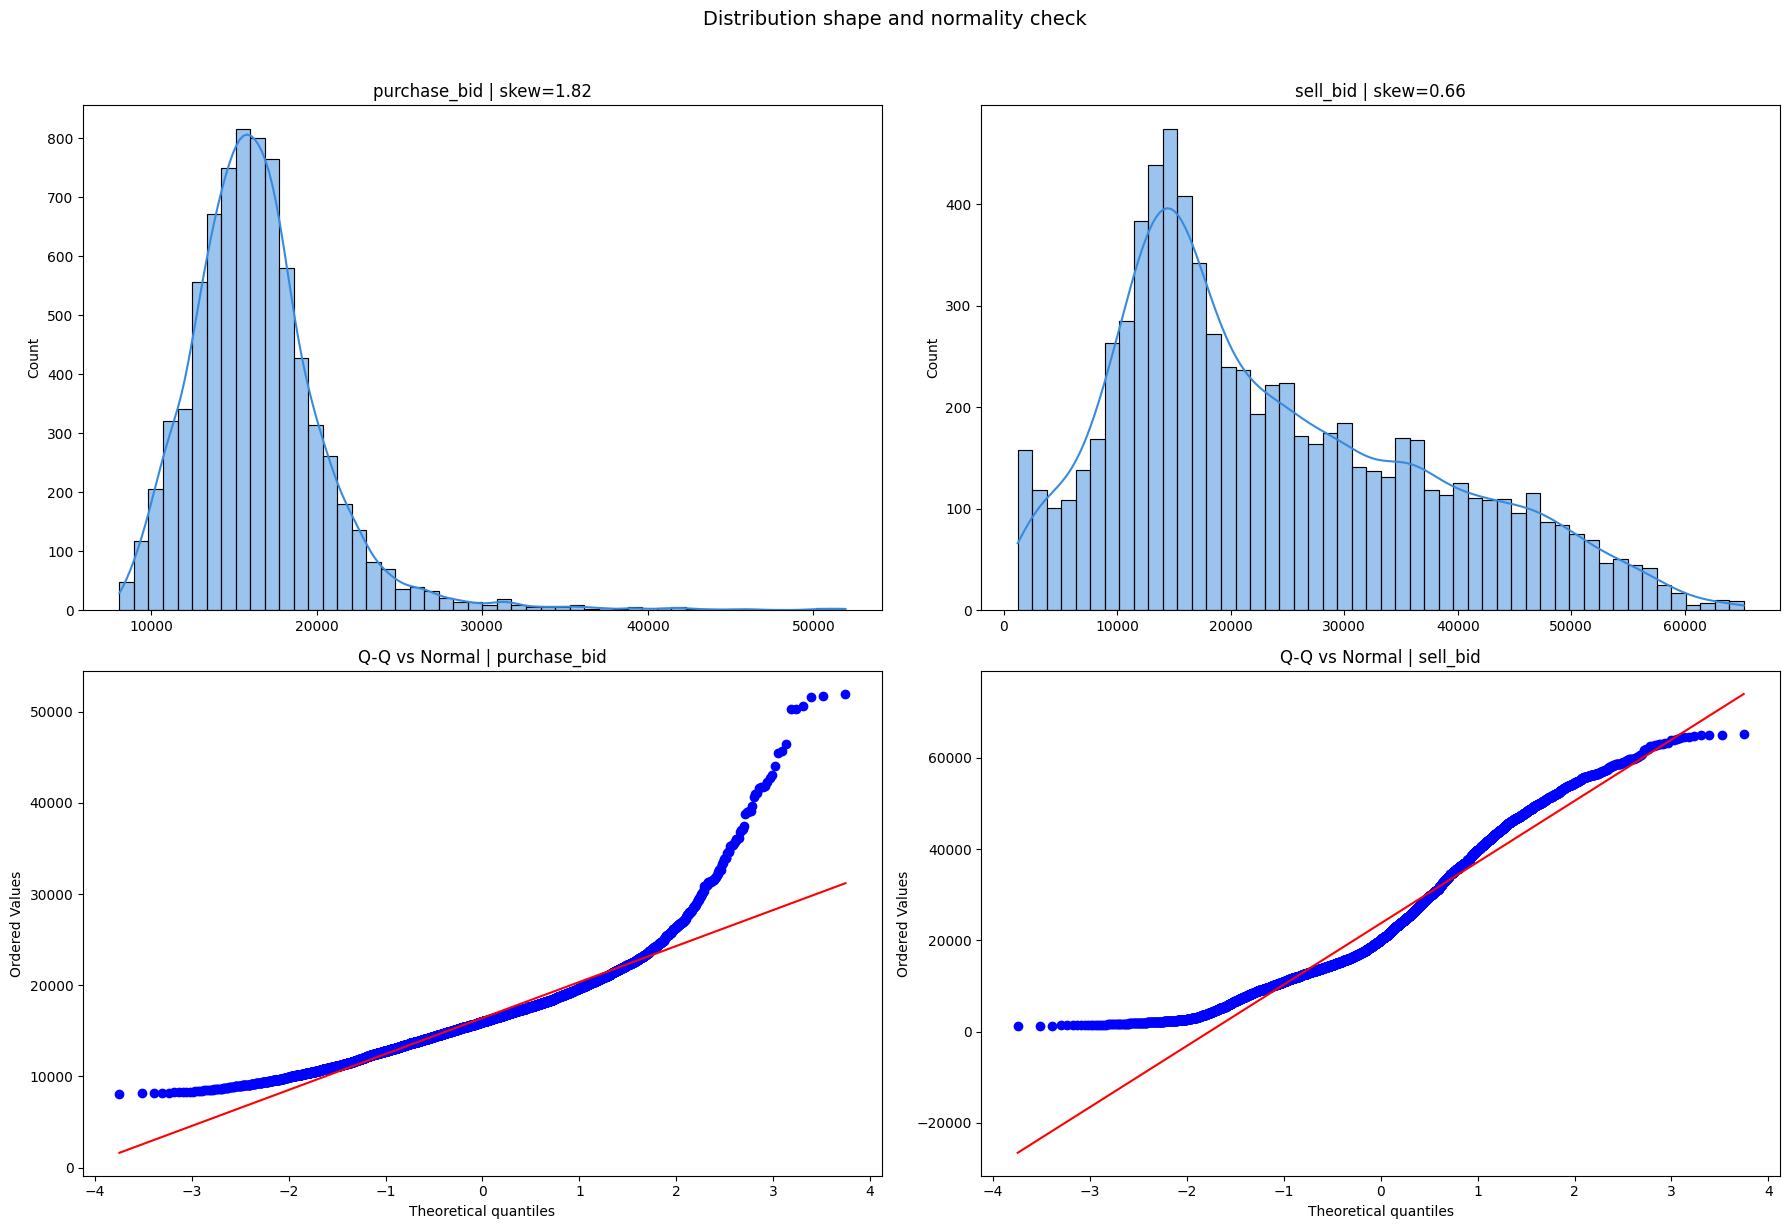


Box-Cox optimal lambda  (λ ≈ 0 ⇒ log,  λ ≈ 0.5 ⇒ sqrt,  λ ≈ 1 ⇒ no transform):
  purchase_bid   | λ*=-0.319 | raw skew=+1.82 | log1p skew=+0.32
  sell_bid       | λ*=+0.433 | raw skew=+0.66 | log1p skew=-0.92


In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import probplot, boxcox

DIST_TARGETS = ["purchase_bid", "sell_bid"]

moments = pd.DataFrame({
    "mean":     clean[DIST_TARGETS].mean(),
    "median":   clean[DIST_TARGETS].median(),
    "std":      clean[DIST_TARGETS].std(),
    "skew":     clean[DIST_TARGETS].skew(),
    "kurtosis": clean[DIST_TARGETS].kurt(),
    "iqr":      clean[DIST_TARGETS].quantile(0.75) - clean[DIST_TARGETS].quantile(0.25),
}).round(3)
print("Distribution moments per target:")
print(moments)

fig, axes = plt.subplots(2, len(DIST_TARGETS), figsize=(18, 12))
for col_idx, col in enumerate(DIST_TARGETS):
    sns.histplot(clean[col], kde=True, bins=50, ax=axes[0, col_idx], color="#378ADD")
    axes[0, col_idx].set_title(f"{col} | skew={clean[col].skew():.2f}")
    axes[0, col_idx].set_xlabel("")

    probplot(clean[col], dist="norm", plot=axes[1, col_idx])
    axes[1, col_idx].set_title(f"Q-Q vs Normal | {col}")

plt.suptitle("Distribution shape and normality check", y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

print("\nBox-Cox optimal lambda  (λ ≈ 0 ⇒ log,  λ ≈ 0.5 ⇒ sqrt,  λ ≈ 1 ⇒ no transform):")
for col in DIST_TARGETS:
    s = clean[col]
    s_pos = s[s > 0]
    if s_pos.empty:
        print(f"  {col:14s} | skipped (no strictly positive values)")
        continue
    _, lam = boxcox(s_pos.values)
    skew_raw = s.skew()
    skew_log = np.log1p(s).skew()
    print(f"  {col:14s} | λ*={lam:+.3f} | raw skew={skew_raw:+.2f} | log1p skew={skew_log:+.2f}")

### Takeaways

**`purchase_bid`:** Box-Cox **λ* ≈ −0.32** (far from 1); **`log1p` pulls skew down to ≈ 0.32**, so a log or Box–Cox family transform is sensible for SARIMA / Gaussian likelihoods and for stabilizing LSTM inputs.

**`sell_bid`:** `log1p` flips skew negative (≈ −0.92)** — prefer **sqrt / Box-Cox** or raw + robust loss over `log1p` for sell volume.

**Modeling hooks:** use **MAE / `regression_l1`** or **Tweedie** in LightGBM when staying on the raw scale; for LSTM on `purchase_bid`, **`log1p` + `RobustScaler`** is a strong default.

## Lag Feature Scouting

Each of the three modeling tracks consumes "the past" differently:

- **SARIMA(p, d, q)(P, D, Q, m)** picks orders directly from ACF/PACF on the seasonally-differenced series - have done this analysis in the Time Series module.
- **LightGBM** needs an explicit lag menu (lag-1, lag-96, lag-672, plus rolling stats). We scout candidates with mutual information.
- **LSTM** needs an input-window length. We pick it from the lag where self-similarity drops off.

Below: mutual-information bar chart over candidate lag features, and a per-hour view of how lag-96 vs lag-672 self-similarity varies — important because some hours are far more autoregressive than others.

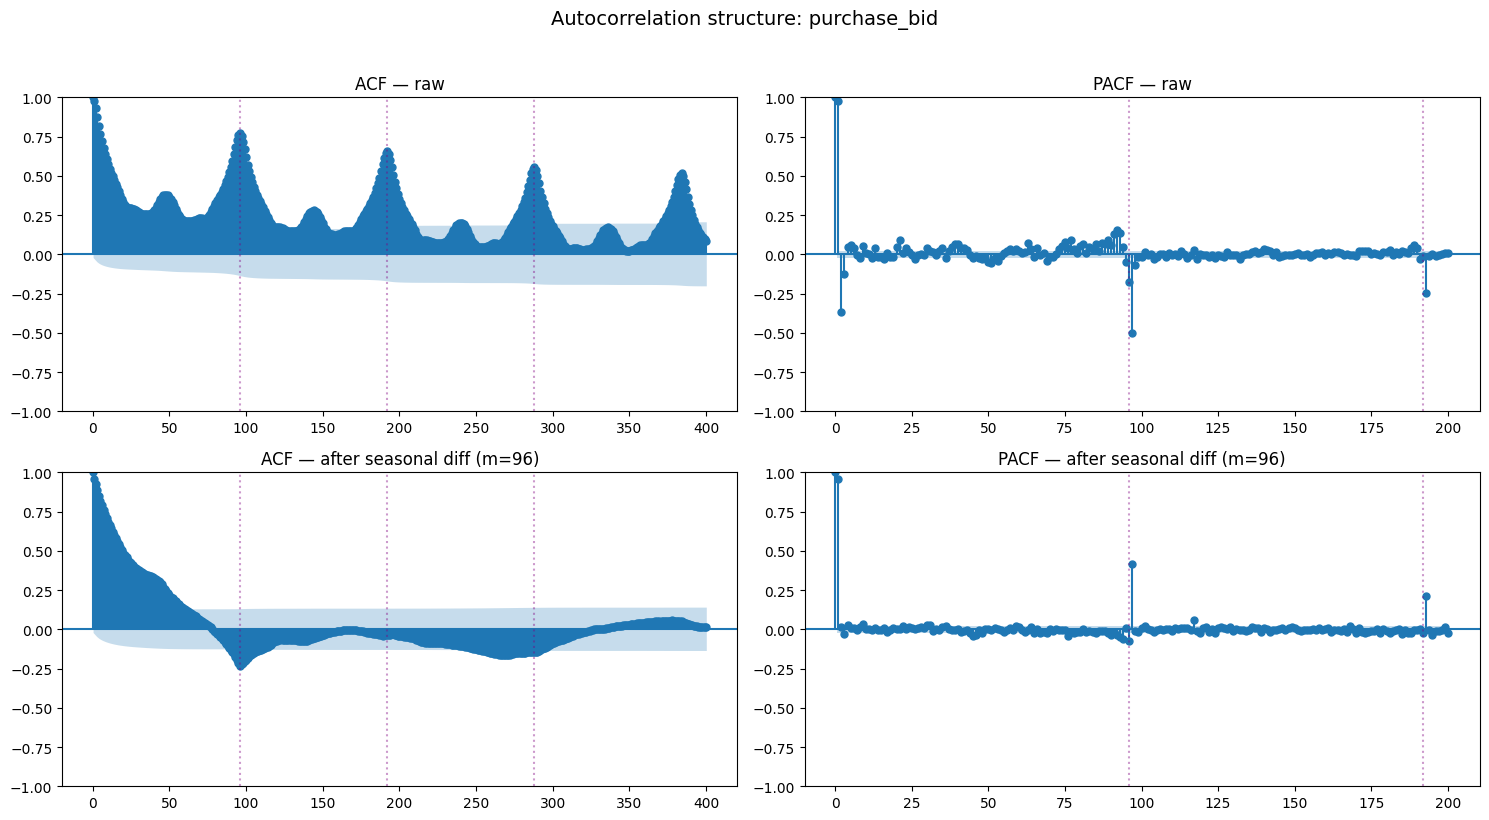

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.feature_selection import mutual_info_regression

LAG_TARGET = "purchase_bid"
series = data.set_index("period_start").asfreq("15min")[LAG_TARGET].dropna()

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
plot_acf(series, lags=400, ax=axes[0, 0]);  axes[0, 0].set_title("ACF — raw")
plot_pacf(series, lags=200, ax=axes[0, 1], method="ywm"); axes[0, 1].set_title("PACF — raw")

s_diff = series.diff(96).dropna()
plot_acf(s_diff, lags=400, ax=axes[1, 0]);  axes[1, 0].set_title("ACF — after seasonal diff (m=96)")
plot_pacf(s_diff, lags=200, ax=axes[1, 1], method="ywm"); axes[1, 1].set_title("PACF — after seasonal diff (m=96)")

for ax in axes.flat:
    for spike in (96, 192, 288, 672):
        if spike <= int(ax.get_xlim()[1]):
            ax.axvline(spike, color="purple", linestyle=":", alpha=0.4)
plt.suptitle(f"Autocorrelation structure: {LAG_TARGET}", y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

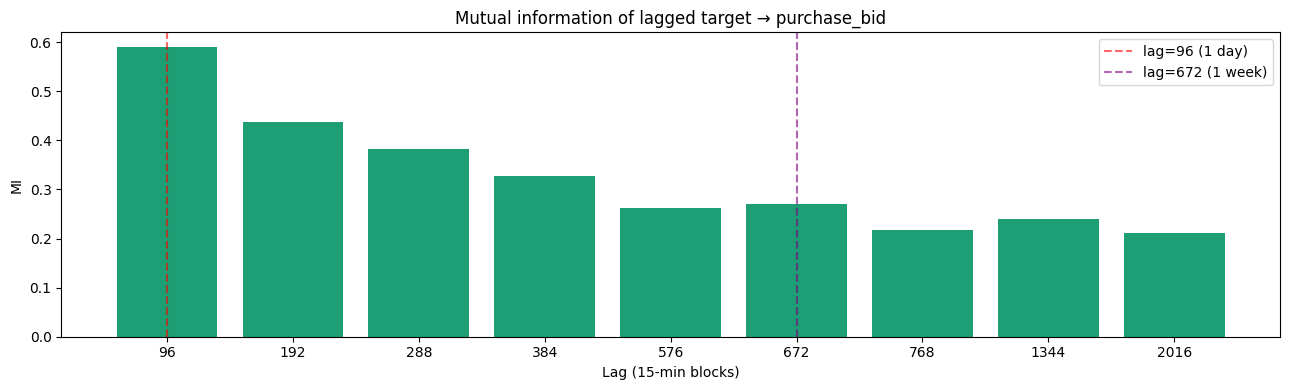

Top-5 lags by MI (use these in the LightGBM feature set):
96     0.5903
192    0.4365
288    0.3819
384    0.3282
672    0.2705
Name: MI, dtype: float64


/var/folders/g9/xjzktt7170ndt92dv26_pntc0000gn/T/ipykernel_50877/4027886880.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


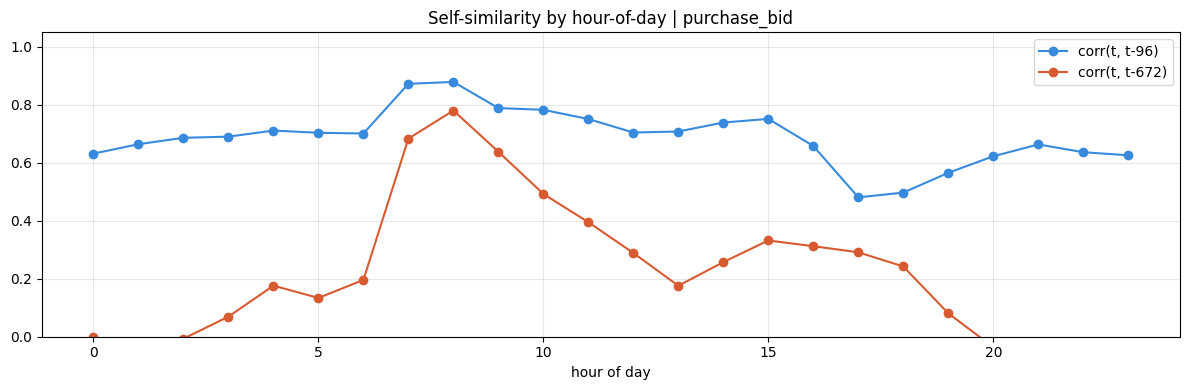

In [13]:
lag_grid = [96, 192, 288, 384, 576, 672, 768, 1344, 2016]
lag_frame = pd.concat({f"lag_{L}": series.shift(L) for L in lag_grid}, axis=1).dropna()
y_aligned = series.loc[lag_frame.index]
mi = mutual_info_regression(lag_frame.values, y_aligned.values, random_state=0)
mi_df = pd.Series(mi, index=lag_grid, name="MI")

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar([str(L) for L in lag_grid], mi_df.values, color="#1D9E75")
for spike, label, color in [(96, "1 day", "red"), (672, "1 week", "purple")]:
    ax.axvline(str(spike), color=color, linestyle="--", alpha=0.6, label=f"lag={spike} ({label})")
ax.set_title(f"Mutual information of lagged target → {LAG_TARGET}")
ax.set_xlabel("Lag (15-min blocks)"); ax.set_ylabel("MI")
ax.legend(); plt.tight_layout(); plt.show()

print("Top-5 lags by MI (use these in the LightGBM feature set):")
print(mi_df.sort_values(ascending=False).head(5).round(4))

hourly = data.copy()
hourly["hr"] = hourly["period_start"].dt.hour
hourly["lag_96"]  = hourly[LAG_TARGET].shift(96)
hourly["lag_672"] = hourly[LAG_TARGET].shift(672)
hourly = hourly.dropna(subset=["lag_96", "lag_672"])
hour_corr = (
    hourly.groupby("hr")
          .apply(lambda g: pd.Series({
              "corr(t, t-96)":  g[LAG_TARGET].corr(g["lag_96"]),
              "corr(t, t-672)": g[LAG_TARGET].corr(g["lag_672"]),
          }))
)
fig, ax = plt.subplots(figsize=(12, 4))
hour_corr.plot(ax=ax, marker="o", color=["#378ADD", "#D85A30"])
ax.set_title(f"Self-similarity by hour-of-day | {LAG_TARGET}")
ax.set_ylim(0, 1.05); ax.set_xlabel("hour of day")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Takeaway (from this run — `purchase_bid`, MI on {96,…,2016})

- **Lag-96 has the highest MI (≈ 0.59)**, then **192, 288, 384** (~0.33–0.44), then **576**, then **672 (≈ 0.27)**. So **intra-week daily repetition** (multiples of 96) dominates; **same-slot last week (672)** still helps but ranks **below** recent same-block days — consistent with the naive baseline where **“mean of last 4 days @ block”** beats **t-672** for purchase.
- **LightGBM:** include lags **{96, 192, 288, 384, 576, 672}** (and optionally **768**) plus **rolling mean/std at 96 and 672**. For a true **7-day-ahead** forecast from a fixed origin, only use lags **≥ 672** *or* features that are known at forecast time (calendar, weather forecast, DAM calendar); never leak **96/192/…** if they fall inside the horizon you are predicting.
- **LSTM:** the MI ladder decays gradually across multiples of 96 — an input length of **≥ 672** (one week) is justified; **1344** (two weeks) is still reasonable if training stays stable.
- Use the **hour-of-day** panel: prioritize **t-672** / calendar splits where **evening** blocks show weaker same-week correlation (aligns with your `is_evening` story).

## Environmental features

In [17]:
import requests
import pandas as pd

df_temp = data.copy()

def get_nci_data(start_date, end_date):
    # Defining cities and their weights for the NCI
    # Mumbai (High Commercial), Delhi (High Residential/Peak), Akola (Heat Epicenter)
    locations = {
        "delhi": {"lat": 28.61, "lon": 77.20, "weight": 0.5},
        "mumbai": {"lat": 19.07, "lon": 72.88, "weight": 0.3},
        "akola": {"lat": 20.70, "lon": 77.01, "weight": 0.2}
    }
    
    all_weather = pd.DataFrame()

    for name, loc in locations.items():
        url = "https://archive-api.open-meteo.com/v1/archive"
        params = {
            "latitude": loc["lat"],
            "longitude": loc["lon"],
            "start_date": start_date,
            "end_date": end_date,
            "daily": "temperature_2m_max",
            "timezone": "Asia/Kolkata"
        }
        res = requests.get(url, params=params).json()
        
        temp_df = pd.DataFrame({
            "date": pd.to_datetime(res["daily"]["time"]),
            f"temp_{name}": res["daily"]["temperature_2m_max"]
        })
        
        if all_weather.empty:
            all_weather = temp_df
        else:
            all_weather = all_weather.merge(temp_df, on="date")

    # Calculate the National Cooling Index (Weighted Average)
    all_weather['NCI'] = 0
    for name, loc in locations.items():
        all_weather['NCI'] += all_weather[f'temp_{name}'] * loc['weight']
    
    return all_weather

# 1. Fetch the multi-city data
weather_master = get_nci_data("2026-02-01", "2026-04-21")

# 2. Merge into your main dataframe
df_temp['date_only'] = df_temp['period_start'].dt.date
weather_master['date_only'] = weather_master['date'].dt.date

df_temp = df_temp.merge(weather_master[['date_only', 'NCI', 'temp_delhi', 'temp_akola', 'temp_mumbai']], on='date_only', how='left')

# 3. Create a non-linear 'Cooling Demand' feature
# This captures the 'spike' effect when NCI crosses 35 degrees
df_temp['cooling_load_factor'] = (df_temp['NCI'] - 30).clip(lower=0)**2

print("NCI and Cooling Load Factor added to data_clean.")

NCI and Cooling Load Factor added to data_clean.


In [39]:
weather_master.to_csv("../../data/weather/weather_master.csv", index=False)

,date,temp_delhi,temp_mumbai,temp_akola,NCI,date_only
0,2026-02-01,20.8,31.8,30.4,26.02,2026-02-01
1,2026-02-02,19.7,33.2,31.3,26.07,2026-02-02
2,2026-02-03,19.6,32.2,30.8,25.62,2026-02-03
3,2026-02-04,20.2,33.8,30.4,26.32,2026-02-04
4,2026-02-05,21.2,33.8,30.5,26.84,2026-02-05
...,...,...,...,...,...,...
75,2026-04-17,40.2,32.5,41.3,38.11,2026-04-17
76,2026-04-18,40.2,34.2,40.8,38.52,2026-04-18
77,2026-04-19,40.1,34.2,41.3,38.57,2026-04-19
78,2026-04-20,39.5,35.0,40.5,38.35,2026-04-20


In [18]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Create figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

# 2. Add Purchase Bid (Primary Axis)
fig.add_trace(
    go.Scatter(
        x=df_temp['period_start'], 
        y=df_temp['purchase_bid'], 
        name="Purchase Bid (MW)",
        line=dict(color="#378ADD", width=1.5),
        opacity=0.8
    ),
    secondary_y=False,
)

# 3. Add Max Temperature (Secondary Axis)
# Note: This will appear as a 'staircase' because it is daily data
fig.add_trace(
    go.Scatter(
        x=df_temp['period_start'], 
        y=df_temp['cooling_load_factor'], 
        name="Max Temp (°C)",
        line=dict(color="#FF4B4B", width=3, dash='dot'),
    ),
    secondary_y=True,
)

# 4. Add layout details
fig.update_layout(
    title_text="<b>Impact of Heatwaves on IEX Purchase Bids (Feb - Apr 2026)</b>",
    hovermode="x unified",
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

# Set y-axes titles
fig.update_yaxes(title_text="<b>Purchase Bid</b> (MW)", secondary_y=False)
fig.update_yaxes(title_text="<b>cooling_load_factore</b> (°C)", secondary_y=True)

fig.show()

In [19]:
# Filter for heatwave periods to see the 'true' driver
heatwave_data = df_temp[df_temp['NCI'] > 34]

# Check correlation of individual cities against purchase_bid
city_cols = [col for col in df_temp.columns if 'temp_' in col]
correlations = heatwave_data[city_cols + ['purchase_bid']].corr()['purchase_bid'].sort_values(ascending=False)

print("Correlation with Purchase Bids during Heatwaves:")
print(correlations)

Correlation with Purchase Bids during Heatwaves:
purchase_bid    1.000000
temp_mumbai     0.215529
temp_delhi     -0.119707
temp_akola     -0.211647
Name: purchase_bid, dtype: float64


In [20]:
# Check if yesterday's temperature in a city predicts today's bids better
for city in city_cols:
    corr_today = df_temp['purchase_bid'].corr(df_temp[city])
    corr_lagged = df_temp['purchase_bid'].corr(df_temp[city].shift(96)) # 96 blocks = 1 day
    print(f"{city} -> Today: {corr_today:.2f}, Lagged (Yesterday): {corr_lagged:.2f}")

temp_delhi -> Today: 0.14, Lagged (Yesterday): 0.15
temp_akola -> Today: 0.03, Lagged (Yesterday): 0.05
temp_mumbai -> Today: 0.15, Lagged (Yesterday): 0.21


In [21]:
import plotly.express as px

# Prepare data for a heatmap
temp_only = df_temp[city_cols + ['date_only']].drop_duplicates().set_index('date_only')

fig = px.imshow(temp_only.T, 
                labels=dict(x="Date", y="City", color="Temp (°C)"),
                title="Regional Temperature Heatmap vs. IEX Spikes",
                color_continuous_scale="Reds")
fig.show()

## Cross-correlation with Weather (Multi-lag CCF)

The earlier blocks computed a single same-day correlation between NCI and bids, then a 1-day lagged comparison per city. To pick weather as an exogenous variable for **SARIMAX** and **LightGBM**, we need three more pieces of evidence:

1. **Direction of causality**: does today's NCI predict tomorrow's bids, or do bids precede temperature swings? CCF over ±10 days makes this visible.
2. **Regime conditioning**: weather correlation is near-zero in February and strong in April. Compute the correlation per month rather than collapsing all data into one number.
3. **Peak vs mean response**: heat affects the *evening peak* far more than the daily mean. Compare both targets explicitly.

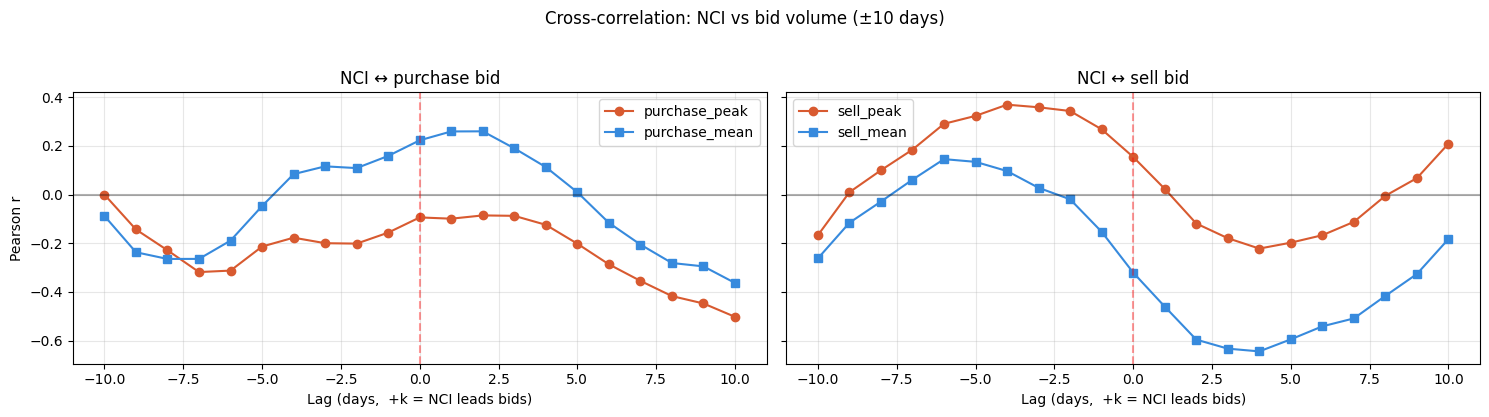

Per-month correlation (regime conditioning):
         n_days  corr(NCI, purchase_peak)  corr(NCI, purchase_mean)  \
month                                                                 
2026-02    28.0                     0.500                     0.500   
2026-03    31.0                     0.480                     0.595   
2026-04    14.0                     0.349                     0.469   

         corr(NCI, sell_peak)  
month                          
2026-02                -0.355  
2026-03                 0.045  
2026-04                 0.079  

Heatwave threshold (NCI p75) = 34.1
                purchase_mean         purchase_peak         sell_mean        
                         mean     std          mean     std      mean     std
regime                                                                       
hot (NCI ≥ p75)       17648.5  2917.1       23519.9  5093.6   23024.1  4820.0
mild                  15681.9  2007.1       23020.4  4354.0   24591.7  3569.2


/var/folders/g9/xjzktt7170ndt92dv26_pntc0000gn/T/ipykernel_50877/4225914875.py:46: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

daily = (
    df_temp.groupby("date_only")
           .agg(purchase_mean=("purchase_bid", "mean"),
                purchase_peak=("purchase_bid", "max"),
                sell_mean=("sell_bid", "mean"),
                sell_peak=("sell_bid", "max"),
                NCI=("NCI", "first"))
           .reset_index()
           .sort_values("date_only")
           .reset_index(drop=True)
)
daily["month"] = pd.to_datetime(daily["date_only"]).dt.to_period("M").astype(str)


def signed_ccf(x: pd.Series, y: pd.Series, max_lag: int = 10) -> pd.Series:
    lags = np.arange(-max_lag, max_lag + 1)
    out = []
    for L in lags:
        xs = x.shift(L)
        mask = xs.notna() & y.notna()
        out.append(np.corrcoef(xs[mask], y[mask])[0, 1] if mask.sum() > 5 else np.nan)
    return pd.Series(out, index=lags, name="ccf")


fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharey=True)
for ax, side in zip(axes, ["purchase", "sell"]):
    ccf_peak = signed_ccf(daily["NCI"], daily[f"{side}_peak"], max_lag=10)
    ccf_mean = signed_ccf(daily["NCI"], daily[f"{side}_mean"], max_lag=10)
    ccf_peak.plot(ax=ax, marker="o", label=f"{side}_peak", color="#D85A30")
    ccf_mean.plot(ax=ax, marker="s", label=f"{side}_mean", color="#378ADD")
    ax.axhline(0, color="black", alpha=0.3)
    ax.axvline(0, color="red", linestyle="--", alpha=0.4)
    ax.set_xlabel("Lag (days,  +k = NCI leads bids)")
    ax.set_ylabel("Pearson r")
    ax.set_title(f"NCI ↔ {side} bid")
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle("Cross-correlation: NCI vs bid volume (±10 days)", y=1.03)
plt.tight_layout(); plt.show()

month_corr = (
    daily.groupby("month")
         .apply(lambda g: pd.Series({
             "n_days": len(g),
             "corr(NCI, purchase_peak)": g["NCI"].corr(g["purchase_peak"]),
             "corr(NCI, purchase_mean)": g["NCI"].corr(g["purchase_mean"]),
             "corr(NCI, sell_peak)":     g["NCI"].corr(g["sell_peak"]),
         }))
         .round(3)
)
print("Per-month correlation (regime conditioning):")
print(month_corr)

heat_thr = daily["NCI"].quantile(0.75)
hot_vs_mild = (
    daily.assign(regime=np.where(daily["NCI"] >= heat_thr, "hot (NCI ≥ p75)", "mild"))
         .groupby("regime")[["purchase_mean", "purchase_peak", "sell_mean"]]
         .agg(["mean", "std"])
         .round(1)
)
print(f"\nHeatwave threshold (NCI p75) = {heat_thr:.1f}")
print(hot_vs_mild)

### Takeaways

- **Read the CCF figure** for the lag where **|r|** is largest for **purchase_peak** vs **NCI** and **sell_peak** vs **NCI** — that lag drives whether **`NCI_t`, `NCI_{t-1}`**, or deeper lags enter **SARIMAX / LightGBM** (same logic as before, now grounded in your plot).
- **Monthly correlations (sample in notebook):** **`corr(NCI, purchase_peak)`** is **~0.50 (Feb), ~0.48 (Mar), ~0.35 (Apr)** — weather tracks **purchase** in **all** months here; April’s drop may mix **shorter sample** (14 days) with regime change. **`corr(NCI, sell_peak)`** is **~-0.36 (Feb)** then **~0.05–0.08 (Mar–Apr)** — **asymmetric**: NCI is **not** a single linear driver of sell like it is of purchase; use **separate exogenous blocks** or **interactions** (e.g. NCI × hour) for sell.
- **Hot vs mild (NCI ≥ p75 ≈ 34.1 °C):** **purchase_mean** is higher when hot (**~17.6k** vs **~15.7k** MW); **sell_mean** is **lower** when hot (**~23.0k** vs **~24.6k**) — consistent with **tighter supply / stronger demand** stories; **peak purchase** is also higher on hot days in this split.
- For **live 7-day-ahead** bids, swap **`/archive`** for **forecast** weather at the decision time and backtest with **only** lags of NCI that would have been known.

## Forecastability & Naive Baselines

We need a **floor** that any SARIMA / LightGBM / LSTM must beat. Two views:

1. **Rolling-origin cross-validation** — several non-overlapping 7-day (672-block) test windows, stepping backward from the end. For each fold, the model uses only data **strictly before** that week. This shows which naive is **stable**, not lucky on one calendar week.
2. **Final holdout** — the **last** 7 days in the CSV, fixed for apples-to-apples benchmarking against tuned models in `ts_pb_tune` / `boost_pb_tune` / LSTM notebooks.

Baselines:

1. `t-96` — yesterday's same 15-min block.
2. `t-672` — last week's same 15-min block.
3. **Mean of the last 4 days @ block** — smoothed seasonal naive.
4. **Weekday × block mean** — training-set average per `(weekday, intraday block)`.

Use **mean CV MAE** to pick the *default* naive story for feature design; use the **final holdout** table as the numeric bar models must clear on the agreed test week.


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from forecasting.evaluation.metrics import regression_metrics

HORIZON = 7 * 96
PERIOD = 96
# Rolling-origin CV: non-overlapping 7-day test blocks stepping backward from the end.
MAX_FOLDS = 12
MIN_TRAIN_ROWS = PERIOD * 21  # ≥3 weeks so t-672 / mean-4-day baselines are well-defined

df_eval = data.set_index("period_start").asfreq("15min")


def naive_repeat_lag(train_series: pd.Series, horizon: int, lag: int) -> np.ndarray:
    base = train_series.iloc[-lag:].values
    return np.tile(base, int(np.ceil(horizon / lag)))[:horizon]


def naive_mean_last_k_days(train_series: pd.Series, horizon: int, k: int = 4) -> np.ndarray:
    tail = train_series.iloc[-k * PERIOD :].values.reshape(k, PERIOD)
    base = np.nanmean(tail, axis=0)
    return np.tile(base, int(np.ceil(horizon / PERIOD)))[:horizon]


def naive_weekday_block_mean(train_series: pd.Series, test_index: pd.DatetimeIndex) -> np.ndarray:
    frame = pd.DataFrame({"y": train_series.dropna()})
    frame["wd"] = frame.index.weekday
    frame["pe"] = frame.index.hour * 4 + frame.index.minute // 15
    table = frame.groupby(["wd", "pe"])["y"].mean()
    return np.array(
        [table.loc[(t.weekday(), t.hour * 4 + t.minute // 15)] for t in test_index]
    )


def smape(y_true, y_pred, eps: float = 1e-9) -> float:
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return float(
        np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + eps)) * 100
    )


targets = ["purchase_bid", "sell_bid"]
baseline_specs = [
    ("Persist t-96 (yesterday)", lambda ts, idx: naive_repeat_lag(ts, HORIZON, 96)),
    ("Persist t-672 (last week)", lambda ts, idx: naive_repeat_lag(ts, HORIZON, 672)),
    ("Mean of last 4 days", lambda ts, idx: naive_mean_last_k_days(ts, HORIZON, k=4)),
    ("Weekday × block mean", lambda ts, idx: naive_weekday_block_mean(ts, idx)),
]


def score_baselines(train_df: pd.DataFrame, test_df: pd.DataFrame):
    rows = []
    for target in targets:
        y_true = test_df[target].values
        train_series = train_df[target].dropna()
        for name, fn in baseline_specs:
            yhat = fn(train_series, test_df.index)
            m = regression_metrics(pd.Series(y_true), pd.Series(yhat))
            rows.append({
                "target": target,
                "baseline": name,
                "MAE": m["mae"],
                "RMSE": m["rmse"],
                "MAPE_pct": m["mape"] * 100,
                "R2": m["r2"],
                "sMAPE_pct": smape(y_true, yhat),
            })
    return rows


n = len(df_eval)
cv_rows = []
for k in range(1, MAX_FOLDS + 1):
    test_end = n - (k - 1) * HORIZON
    test_start = test_end - HORIZON
    if test_start < 0:
        break
    train = df_eval.iloc[:test_start]
    test = df_eval.iloc[test_start:test_end]
    if len(train) < MIN_TRAIN_ROWS:
        break
    for row in score_baselines(train, test):
        row["fold"] = k
        row["test_start"] = test.index.min()
        row["test_end"] = test.index.max()
        cv_rows.append(row)

cv_long = pd.DataFrame(cv_rows)
n_folds_used = int(cv_long["fold"].nunique()) if len(cv_long) else 0
cv_summary = (
    cv_long.groupby(["target", "baseline"], sort=False)[["MAE", "RMSE", "MAPE_pct", "sMAPE_pct"]]
    .agg(["mean", "std"])
    .round(2)
)
print(
    f"Rolling-origin CV: {n_folds_used} non-overlapping 7-day folds "
    f"(each test = {HORIZON} blocks; training set is strictly before each test). "
    f"MIN_TRAIN_ROWS = {MIN_TRAIN_ROWS}."
)
print("\nMean ± std over folds:")
print(cv_summary)

cv_mae_mean = cv_long.groupby(["target", "baseline"])["MAE"].mean().reset_index(name="mean_MAE")
cv_champions = (
    cv_mae_mean.sort_values(["target", "mean_MAE"]).groupby("target", sort=False).first().reset_index()
)
print("\nLowest mean CV MAE (naive champion per target):")
print(cv_champions.to_string(index=False))

# --- Final single holdout (last 7 days): same split for model benchmarking ---
train, test = df_eval.iloc[:-HORIZON], df_eval.iloc[-HORIZON:]
print(f"\n--- Final holdout (benchmark week for fitted models) ---")
print(f"Train : {train.index.min()} → {train.index.max()}  ({len(train):,} rows)")
print(f"Test  : {test.index.min()} → {test.index.max()}   ({len(test):,} rows)")

records, all_preds = [], {}
for target in targets:
    y_true = test[target].values
    train_series = train[target].dropna()
    preds = {name: fn(train_series, test.index) for name, fn in baseline_specs}
    all_preds[target] = preds
    for name, yhat in preds.items():
        m = regression_metrics(pd.Series(y_true), pd.Series(yhat))
        records.append({
            "target": target,
            "baseline": name,
            "MAE": m["mae"],
            "RMSE": m["rmse"],
            "MAPE_pct": m["mape"] * 100,
            "R2": m["r2"],
            "sMAPE_pct": smape(y_true, yhat),
        })

baselines_df = (
    pd.DataFrame(records)
    .set_index(["target", "baseline"])
    .round(2)
    .sort_index()
)
print("\nNaive scores on the final held-out 7-day window:")
baselines_df

# Save holdout naive preds (same CSV layout as pb_boost_*.csv)
from forecasting.evaluation.naive_export import export_holdout_best_naive

_naive_meta = export_holdout_best_naive()
print("Saved:", _naive_meta["pb_path"], _naive_meta["sb_path"])
print("Naive baselines used:", _naive_meta["pb_baseline"], "|", _naive_meta["sb_baseline"])


Rolling-origin CV: 7 non-overlapping 7-day folds (each test = 672 blocks; training set is strictly before each test). MIN_TRAIN_ROWS = 2016.

Mean ± std over folds:
                                            MAE              RMSE           \
                                           mean      std     mean      std   
target       baseline                                                        
purchase_bid Persist t-96 (yesterday)   3002.10  1012.89  3666.20  1084.47   
             Persist t-672 (last week)  3273.48  1296.55  3948.77  1520.34   
             Mean of last 4 days        2521.01   816.63  3101.17  1012.39   
             Weekday × block mean       2982.59   827.93  3614.41   961.10   
sell_bid     Persist t-96 (yesterday)   3786.58  1670.80  4665.84  1863.67   
             Persist t-672 (last week)  5448.51  2305.62  6504.56  2431.67   
             Mean of last 4 days        4516.91  2134.45  5317.28  2297.46   
             Weekday × block mean       6747.18  1912.9

MAE      RMSE  MAPE_pct    R2  \
target       baseline                                                       
purchase_bid Mean of last 4 days        1511.59   2075.93     10.20  0.44   
             Persist t-672 (last week)  2048.94   2522.19     14.92  0.17   
             Persist t-96 (yesterday)   2221.57   2956.35     14.76 -0.14   
             Weekday × block mean       3274.44   3993.82     26.68 -1.08   
sell_bid     Mean of last 4 days        3612.09   4560.26     18.48  0.94   
             Persist t-672 (last week)  5591.78   6995.80     26.69  0.86   
             Persist t-96 (yesterday)   3016.40   3922.74     19.66  0.96   
             Weekday × block mean       8858.48  11139.03     40.98  0.65   

                                        sMAPE_pct  
target       baseline                              
purchase_bid Mean of last 4 days            10.55  
             Persist t-672 (last week)      14.79  
             Persist t-96 (yesterday)       16.40  
             Weekday × block mean           22.33  
sell_bid     Mean of last 4 days            16.58  
             Persist t-672 (last week)      26.06  
             Persist t-96 (yesterday)       15.86  
             Weekday × block mean           34.69

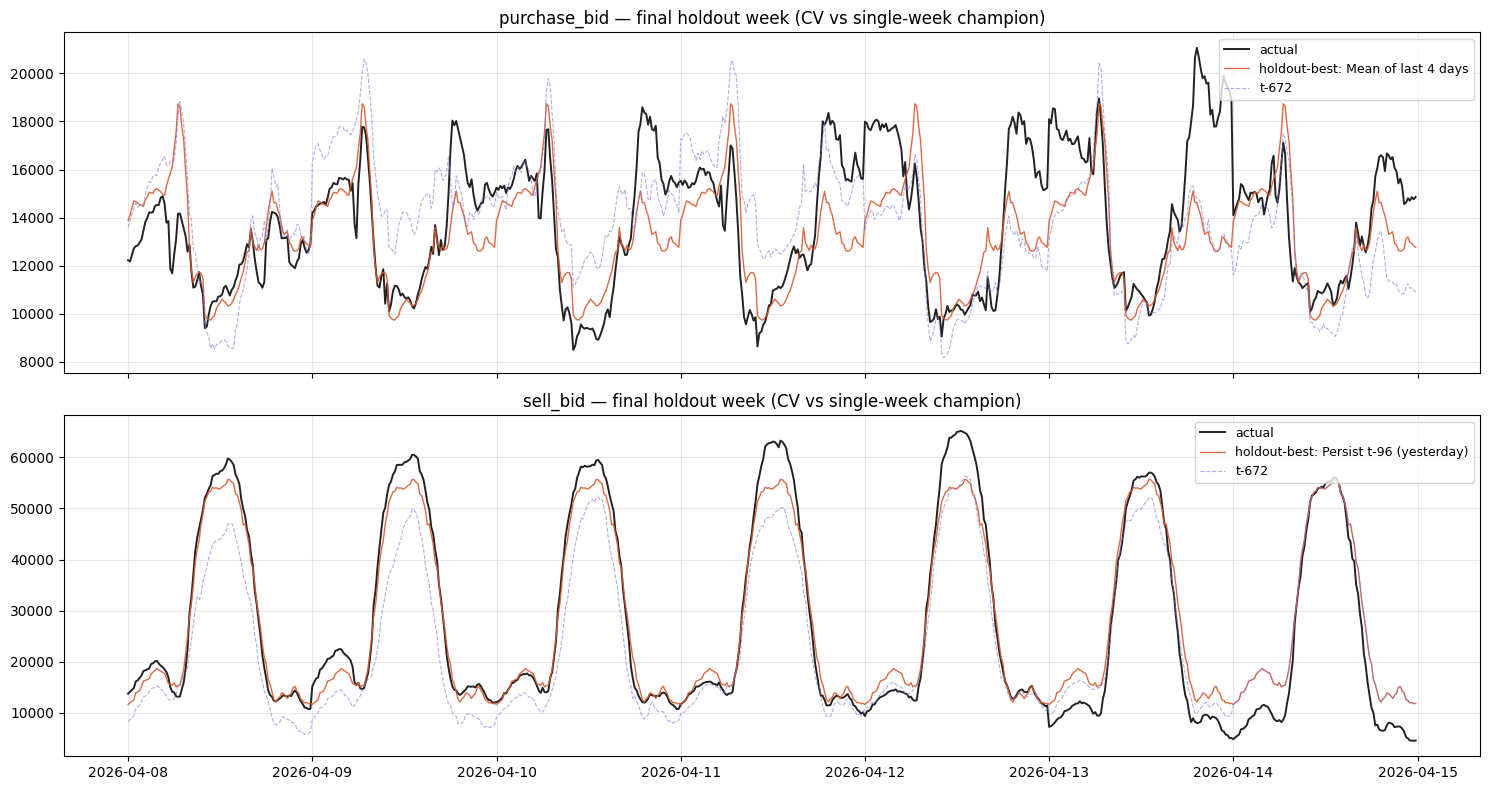

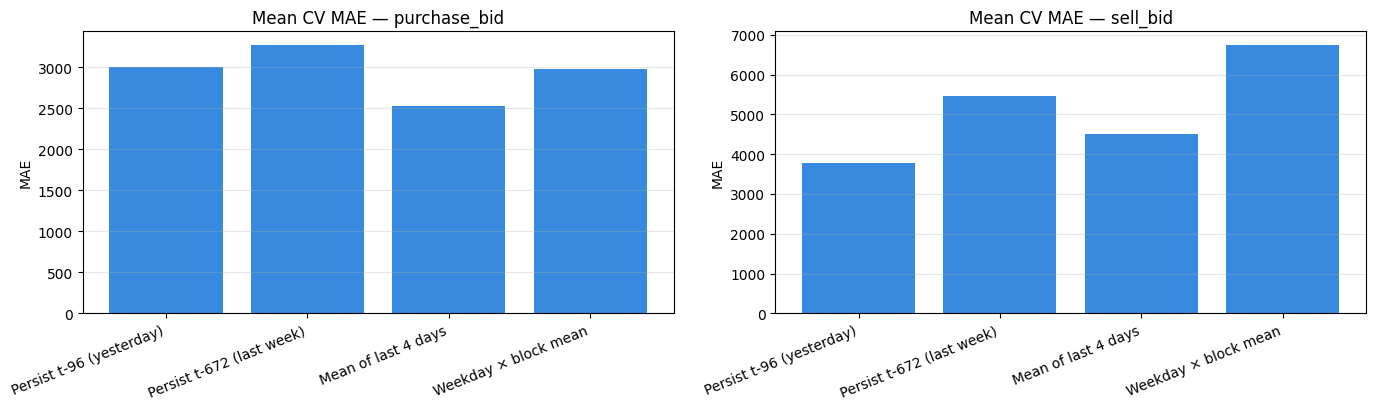

Best naive on **final** holdout week:
                              baseline      MAE     RMSE  MAPE_pct  sMAPE_pct
target                                                                       
purchase_bid       Mean of last 4 days  1511.59  2075.93     10.20      10.55
sell_bid      Persist t-96 (yesterday)  3016.40  3922.74     19.66      15.86

Best naive by **mean CV MAE**:
                              baseline  mean_MAE_CV
target                                             
purchase_bid       Mean of last 4 days  2521.005086
sell_bid      Persist t-96 (yesterday)  3786.577700


In [34]:
fig, axes = plt.subplots(len(targets), 1, figsize=(15, 4 * len(targets)), sharex=True)
if len(targets) == 1:
    axes = [axes]

for ax, target in zip(axes, targets):
    holdout_best = baselines_df.loc[target]["MAE"].idxmin()
    cv_best = cv_champions.loc[cv_champions["target"] == target, "baseline"].iloc[0]
    ax.plot(test.index, test[target].values, label="actual", color="#222", lw=1.4)
    ax.plot(
        test.index, all_preds[target][holdout_best],
        label=f"holdout-best: {holdout_best}", color="#D85A30", lw=1.0, alpha=0.9,
    )
    if cv_best != holdout_best:
        ax.plot(
            test.index, all_preds[target][cv_best],
            label=f"CV-best: {cv_best}", color="#1D9E75", lw=0.9, alpha=0.85, linestyle=":",
        )
    ax.plot(
        test.index, all_preds[target]["Persist t-672 (last week)"],
        label="t-672", color="#7F77DD", lw=0.8, alpha=0.6, linestyle="--",
    )
    ax.set_title(f"{target} — final holdout week (CV vs single-week champion)")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Mean CV MAE by baseline (which naive is stable across weeks?)
order = [name for name, _ in baseline_specs]
fig2, axes2 = plt.subplots(1, len(targets), figsize=(7 * len(targets), 4.2))
if len(targets) == 1:
    axes2 = [axes2]
for ax, target in zip(axes2, targets):
    sub = cv_long.loc[cv_long["target"] == target].groupby("baseline")["MAE"].mean().reindex(order)
    ax.bar(range(len(sub)), sub.values, color="#378ADD")
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub.index, rotation=22, ha="right")
    ax.set_title(f"Mean CV MAE — {target}")
    ax.set_ylabel("MAE")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

best_holdout = (
    baselines_df.reset_index()
    .loc[lambda d: d.groupby("target")["MAE"].idxmin()]
    .set_index("target")[["baseline", "MAE", "RMSE", "MAPE_pct", "sMAPE_pct"]]
)
print("Best naive on **final** holdout week:")
print(best_holdout)
print("\nBest naive by **mean CV MAE**:")
print(cv_champions.set_index("target").rename(columns={"mean_MAE": "mean_MAE_CV"}))


### Takeaway

- **CV vs one week:** If the champion on the final holdout differs from the **lowest mean CV MAE** baseline, the single week is noisy — prefer the CV winner for architectural choices (e.g. lag features), but still report model vs **both** when you write up results.
- **Purchase vs sell** often pick different champions; keep separate bars or separate feature templates per target if CV says so.
- Re-run after refreshing `data` — fold count follows `MIN_TRAIN_ROWS` and `MAX_FOLDS`. Increase `MIN_TRAIN_ROWS` if you add baselines that need longer history.
